In [1]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
import wandb

# 1. Initialize Weights & Biases - to observe real time graphs
wandb.login()
wandb.init(
    project="pet-segmentation",
    config={
        "batch_size": 32,
        "image_size": 256,
        "val_split": 0.1
    }
)
config = wandb.config

# 2. SSL workaround for MacOS (from your snippet)
try:
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context
except ImportError:
    pass

# 3. Provided Transform Class - see Kaggle
class SegmentationTransform:
    def __init__(self, size=(256, 256)):
        self.size = size
        self.image_transform = transforms.Compose([
            transforms.Resize(self.size),
            transforms.ToTensor()
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize(self.size, interpolation=transforms.InterpolationMode.NEAREST),
            transforms.PILToTensor()
        ])

    def __call__(self, image, target):
        image = self.image_transform(image)
        target = self.mask_transform(target).squeeze(0).long() - 1  # [1, H, W] → [H, W], label remap
        return image, target

# 4. Load the Full Dataset
full_dataset = OxfordIIITPet(
    root='./data',
    target_types='segmentation',
    download=True,
    transforms=SegmentationTransform(size=(config.image_size, config.image_size))
)

# 5. Create Train / Validation Split for Early Stopping
val_size = int(len(full_dataset) * config.val_split)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # Seed for reproducibility
)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

# 6. Provided Test Dataset Loader
def load_images(filename: str, image_shape: tuple = (3, 256, 256)):
    df = pd.read_csv(filename)

    images = []
    for _, row in df.iterrows():
        flat = eval(row['image'])  # Convert stringified list back to list
        tensor = torch.tensor(flat, dtype=torch.float32).reshape(image_shape)
        images.append(tensor)

    return torch.stack(images)  # [B, C, H, W]

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\david\_netrc.
wandb: Currently logged in as: potkaan99 (potkaan99-charles-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training samples: 3312
Validation samples: 368


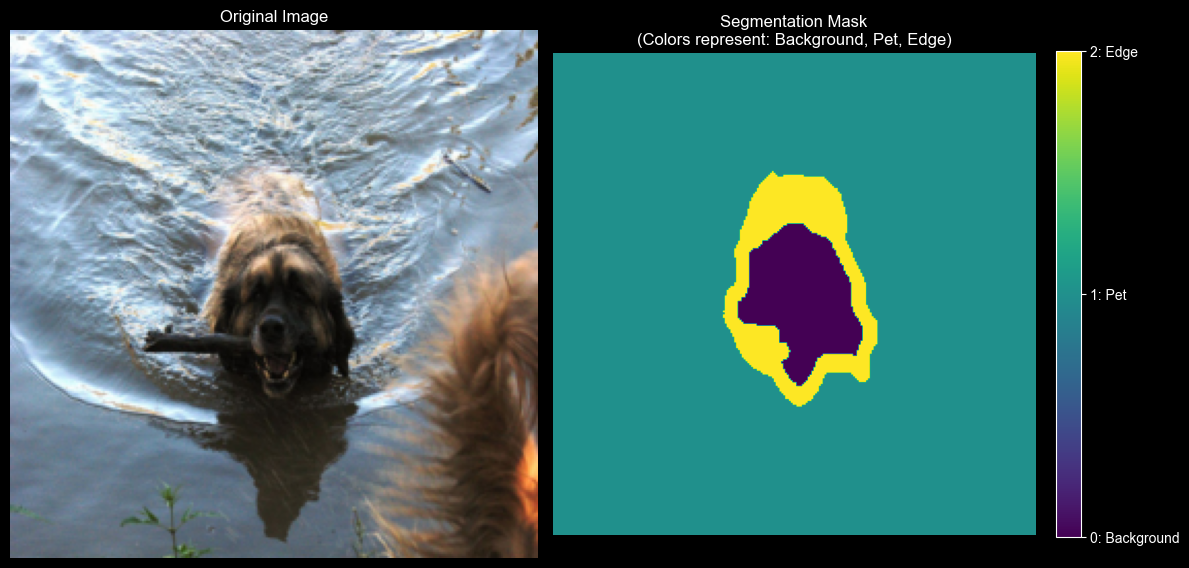

In [6]:
import matplotlib.pyplot as plt

# 1. Grab a single sample from the dataset
image, mask = train_dataset[0]

# 2. Prepare the Image for Matplotlib
# Convert [3, 256, 256] -> [256, 256, 3]
# Since we didn't add normalization to the dataset transform, the values are safely in [0, 1]
image_np = image.permute(1, 2, 0).numpy()

# 3. Prepare the Mask
# The mask is already [256, 256], so we just convert it to numpy
mask_np = mask.numpy()

# 4. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot Original Image
axes[0].imshow(image_np)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Plot Segmentation Mask
# Using a colormap (like 'viridis') makes the 3 distinct integers pop out with different colors
im = axes[1].imshow(mask_np, cmap='viridis')
axes[1].set_title("Segmentation Mask\n(Colors represent: Background, Pet, Edge)")
axes[1].axis('off')

# Add a colorbar to the mask so you can see exactly which color maps to 0, 1, and 2
cbar = fig.colorbar(im, ax=axes[1], ticks=[0, 1, 2], fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(['0: Background', '1: Pet', '2: Edge'])

plt.tight_layout()
plt.show()

In [2]:
def compute_iou(mask_true: np.ndarray, mask_pred: np.ndarray, num_classes: int = 3) -> float:
    """Computes mean Intersection over Union (mIoU) for multi-class masks."""
    ious = []

    for cls in range(num_classes):
        true_cls = mask_true == cls
        pred_cls = mask_pred == cls

        intersection = np.logical_and(true_cls, pred_cls).sum()
        union = np.logical_or(true_cls, pred_cls).sum()

        if union == 0:
            continue  # skip this class — not present in either pred or true

        iou = intersection / union
        ious.append(iou)

    if not ious:
        return 1.0  # If no classes are present in either mask, define mIoU as perfect

    return np.mean(ious)

In [3]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms

class CustomSegmentationModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # Backbone setup (unchanged)
        weights = ResNet50_Weights.DEFAULT
        base_model = resnet50(weights=weights, replace_stride_with_dilation=[False, True, True])
        self.backbone = nn.Sequential(*list(base_model.children())[:-2])

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        # UPGRADE: A learned decoder instead of a bilinear upsample!
        # The backbone outputs [Batch, 2048 channels, 32, 32]
        self.decoder = nn.Sequential(
            # 1. Reduce the massive 2048 channels to 256 and process the features
            nn.Conv2d(2048, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # 2. Step up to 64x64
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 3. Step up to 128x128
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 4. Step up to 256x256
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 5. Final pixel-wise classification into our 3 classes
            nn.Conv2d(32, num_classes, kernel_size=1)
        )

    def train(self, mode=True):
        super().train(mode)
        if not next(self.backbone.parameters()).requires_grad:
            self.backbone.eval()

    def forward(self, x):
        x = self.normalize(x)
        features = self.backbone(x)
        mask = self.decoder(features) # Passes through our new learned upsampler
        return mask

model = CustomSegmentationModel(num_classes=3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# class CustomSegmentationModel(nn.Module)

weights=ResNet50_Weights.DEFAULT: We download the pre-trained "brain" of ResNet50, which has already looked at millions of images on ImageNet and knows how to find fur, eyes, and shapes.

replace_stride_with_dilation: Normally, ResNet50 aggressively shrinks your 256x256 image down to a tiny 8x8 grid to save memory. By using "dilation" (spreading out the convolution filters instead of skipping pixels), we force ResNet50 to keep the image at a much higher resolution of 32x32. 8x8 grid cannot possibly hold the detail required to draw a 1-pixel thin "Edge" mask.

[:-2]: A standard ResNet50 ends with an "Average Pool" and a "Linear" layer to spit out a single text classification. We chop off those last 2 layers, keeping only the spatial feature maps.

self.normalize: The pre-trained ResNet50 only works if the colors of the input image are mathematically shifted to match the ImageNet dataset. Normally part of SegmentationTransform, however that was provided so we put it here


requires_grad = False: We lock the backbone's weights. We don't want our untrained, randomly initialized decoder to send chaotic error signals backward and destroy ResNet50's pre-trained knowledge during the first few epochs.

## Decoder

When the image exits the backbone, it is a dense block of data: 2048 channels (representing 2048 different patterns like "fur texture" or "eye shape") at a 32x32 spatial resolution.

The Bottleneck (Conv2d): 2048 channels is massive. We use a standard convolution to compress those 2048 patterns down to 256 essential patterns, making the math much faster for GPU.

The Upsampling (ConvTranspose2d): A "Transposed Convolution" (often called a Deconvolution) is the mathematical opposite of a normal convolution. Instead of summarizing pixels to shrink an image, it learns to expand pixels.

Step 1: Expands the grid from 32x32 → 64x64

Step 2: Expands the grid from 64x64 → 128x128

Step 3: Expands the grid from 128x128 → 256x256 (Back to original size!)

The Final Layer (Conv2d(32, num_classes)): Now that we are back at 256x256 resolution, this final layer acts as a sorter. It looks at the 32 decoded features for every single pixel and assigns that pixel to exactly one of our 3 classes (Background, Pet, or Edge).

## Training
```
  def train(self, mode=True):
    super().train(mode)
    if not next(self.backbone.parameters()).requires_grad:
        self.backbone.eval()
```
Batch Normalization layers constantly calculate the average color/intensity of a batch of images while training.
Normally, if you freeze a model (requires_grad=False) but put it in .train() mode, PyTorch will still update those internal Batch Norm averages. Because our un-normalized images are weird, it would ruin the backbone!

In [4]:
import torch.optim as optim
from tqdm import tqdm

max_epochs = 50
patience = 7
best_val_iou = 0.0
epochs_without_improvement = 0
unfreeze_epoch = 5  # We will unfreeze the backbone here

criterion = nn.CrossEntropyLoss()

# Start by optimizing ONLY the head with a higher learning rate
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print(f"Starting Two-Stage training on {device}")


# 1. Initialize the scaler before your epoch loop
scaler = torch.cuda.amp.GradScaler()
for epoch in range(max_epochs):

    # --- UNFREEZE LOGIC ---
    if epoch == unfreeze_epoch:
        print("\n Unfreez the backbone")
        for param in model.backbone.parameters():
            param.requires_grad = True

        # Re-initialize the optimizer to include ALL parameters, but with a lower learning rate so we don't destroy the pretrained weights
        optimizer = optim.AdamW(model.parameters(), lr=1e-4)


    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]"):
        images, targets = images.to(device), targets.to(device)

        # Data Augmentation (Horizontal Flip)
        if torch.rand(1).item() > 0.5:
            images = torch.flip(images, dims=[3])
            targets = torch.flip(targets, dims=[2])

        optimizer.zero_grad()

        # 2. Wrap the forward pass and loss in autocast
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, targets)

        # 3. Scale the loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_ious = []

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Val]"):
            images, targets = images.to(device), targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            targets_np = targets.cpu().numpy()

            for i in range(len(preds)):
                val_ious.append(compute_iou(targets_np[i], preds[i]))

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = np.mean(val_ious)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val mIoU: {avg_val_iou:.4f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_miou": avg_val_iou
    })

    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_segmentation_model.pth")
        print(f"New best Val mIoU! Model saved.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered after {epoch + 1} epochs!")
        break

🚀 Starting Two-Stage training on cuda!


C:\Users\david\AppData\Local\Temp\ipykernel_20280\3835043503.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/50 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.08it/s]


Train Loss: 0.4678 | Val Loss: 0.3293 | Val mIoU: 0.6234
🌟 New best Val mIoU! Model saved.


Epoch 2/50 [Val]: 100%|██████████| 12/12 [00:02<00:00,  4.23it/s]


Train Loss: 0.3077 | Val Loss: 0.2871 | Val mIoU: 0.6721
🌟 New best Val mIoU! Model saved.


...

Train Loss: 0.0353 | Val Loss: 0.2447 | Val mIoU: 0.8066
⚠️ No improvement for 3 epoch(s).


Epoch 49/50 [Val]: 100%|██████████| 12/12 [00:01<00:00,  6.33it/s]


Train Loss: 0.0352 | Val Loss: 0.2427 | Val mIoU: 0.8075
⚠️ No improvement for 4 epoch(s).


Epoch 50/50 [Val]: 100%|██████████| 12/12 [00:01<00:00,  6.20it/s]


Train Loss: 0.0349 | Val Loss: 0.2435 | Val mIoU: 0.8080
🌟 New best Val mIoU! Model saved.


## Parameter choice
max_epochs = 50: high ceiling. Because Im training on powerful graphics card and we are using Early Stopping. We set it high so the model has plenty of room to run until it naturally stops improving.

patience = 7: This is our Early Stopping trigger. If the Validation mIoU doesn't hit a new high score for 7 consecutive epochs, we kill the training.
 If patience is 2, training might stop prematurely just because the model had two "unlucky" batches. 7 gives the model a fair chance to recover from a temporary dip before we officially declare it has stopped learning.

unfreeze_epoch = 5: The exact moment we shift from Stage 1 (warming up the decoder) to Stage 2 (fine-tuning the whole model). The randomly initialized decoder usually takes about 3 to 5 epochs to figure out the basic math of upsampling. If we unfreeze at 1, the decoder is still outputting pure garbage, which sends chaotic error signals backward and damages the ResNet backbone. 5 is a safe "warm-up" period.

criterion = nn.CrossEntropyLoss(): The standard way to calculate error when a model has to choose between distinct categories (Background, Pet, or Edge).

optimizer = optim.AdamW(...): The "mechanic" that updates the model's weights based on the loss. AdamW is the modern standard because it handles weight decay  much better than regular Adam.

filter(lambda p: p.requires_grad...): This is a Python filter. Only grab the ones that are not frozen

lr=1e-3 (0.001): The Learning Rate.: 0.001 is considered a starting pace. Since the decoder is completely blank (random weights), it needs to take big, fast steps to quickly learn how to draw borders.

# scaler
scaler = torch.cuda.amp.GradScaler()
 Because we are going to use torch.autocast to do math in float16 instead of float32 (saving huge amounts of VRAM and time on RTX 5070), the numbers can sometimes get so microscopically small that the computer rounds them to zero. The GradScaler artificially multiplies the gradients by a massive number before updating the weights, and then scales them back down, completely preventing that issue.

# after unfreeze
Unlock the Backbone: We loop through the ResNet50 and set requires_grad = True. The whole network is now alive and trainable.

Rebuild the Optimizer: We completely throw away the old Stage 1 optimizer and create a brand new one. we no longer use the filter(...). We just pass model.parameters(), meaning the optimizer is now tracking the entire network.

lr=1e-4 (0.0001): We instantly drop the learning rate by a factor of 10.



# Data Augmentation (Horizontal Flip)

```
if torch.rand(1).item() > 0.5:
        images = torch.flip(images, dims=[3])
        targets = torch.flip(targets, dims=[2])
```
We have a limited number of pet photos. To prevent the model from memorizing them, we artificially double our dataset by randomly flipping images like a mirror.

torch.rand(1).item() > 0.5:  There is a 50% chance the code inside this block runs.
We need to flip the masks as well here.

# Autocast
torch.autocast(...): This activates the RTX Tensor Cores. For the math inside this block, temporarily squish the numbers down from 32-bit to 16-bit. It's slightly less precise, but 2x faster - so the operations finish in reasonable time


# 3. Scale the loss and backpropagate

```  scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
```

Because we used 16-bit math (autocast), the error numbers might be so tiny (like 0.000000001) that the computer rounds them to zero.
.scale(loss): Multiplies the loss by a massive number to make it safely large.

scaler.step(optimizer): The optimizer takes those calculations and actually changes the weights of the model to be slightly better. It steps down the gradient.

scaler.update(): Adjusts the multiplier scale for the next batch so the numbers stay stable.

In [5]:
import torch
import pandas as pd
from tqdm import tqdm

# 1. Load the previously saved best model weights
model.load_state_dict(torch.load("best_segmentation_model.pth"))
model.to(device)
model.eval()

# 2. Load the test images using the provided function
print("Loading test images...")

test_tensor = load_images(r"C:\Users\david\PycharmProjects\data-science-2-petra\Practicals\04_neural_networks\data\test_images.csv")  # Shape: [128, 3, 256, 256]

# We will put the tensor into a DataLoader just to process it in batches.

test_dataset = torch.utils.data.TensorDataset(test_tensor)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

predictions = []

# 3. Run Inference
print("🔍 Generating predictions on the test set...")
with torch.no_grad():
    # We use autocast like in training
    with torch.autocast(device_type='cuda', dtype=torch.float16):
        for batch in tqdm(test_loader, desc="Testing"):
            images = batch[0].to(device)
            outputs = model(images)

            # Extract the predicted class index for each pixel -> Shape: [B, 256, 256]
            preds = torch.argmax(outputs, dim=1)

            # Flatten each 256x256 mask into a 1D list of 65536 values
            # .view(B, -1) flattens the spatial dimensions
            # .cpu().tolist() converts the tensors into standard Python lists
            preds_list = preds.view(preds.size(0), -1).cpu().tolist()

            predictions.extend(preds_list)

# 4. Format and save the CSV
print("Formatting submission file...")
submission_data = []
for idx, mask_list in enumerate(predictions):
    submission_data.append({
        'id': idx,
        'mask': mask_list,
        'Usage': 'Public'
    })

submission_df = pd.DataFrame(submission_data)


save_path = r'C:\Users\david\PycharmProjects\data-science-2-petra\Practicals\Data\grandmaster_submission.csv'
submission_df.to_csv(save_path, index=False)

print(f"✅ Success! 'grandmaster_submission.csv' is ready to be uploaded to the competition!")

📥 Loading test images...
🔍 Generating predictions on the test set...


Testing: 100%|██████████| 4/4 [00:00<00:00,  8.18it/s]


Formatting submission file...
✅ Success! 'grandmaster_submission.csv' is ready to be uploaded to the competition!
